In [36]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tqdm as tqdm

### Read images

In [37]:
img1 = cv2.imread('assignment_2_materials/shanghai-21.png')
img2 = cv2.imread('assignment_2_materials/shanghai-22.png')
img3 = cv2.imread('assignment_2_materials/shanghai-23.png')
gray_img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
gray_img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

### SIFT detector


In [38]:
def get_sift(gray_img1, gray_img2):
    sift_detector=cv2.SIFT_create()

    # Detect keypoints and descriptors
    keypoints1, descriptors1 = sift_detector.detectAndCompute(gray_img1, None)
    keypoints2, descriptors2 = sift_detector.detectAndCompute(gray_img2, None)

    # Match descriptors using KNN
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(descriptors1, descriptors2, k=2)

    # Apply ratio test
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)
    good_matches = sorted(good_matches, key=lambda x: x.distance)
    return good_matches, keypoints1, keypoints2, descriptors1, descriptors2

### Rnsac + Homography computations

In [39]:
def compute_homography(src_pts, dst_pts):

    if len(src_pts) < 4:
        raise ValueError("Need at least 4 points to compute homography")
    # Aih = 0
    # [-x, -y, -1,  0,  0,  0, x * x', y * x', x']
    # [ 0,  0,  0, -x, -y, -1, x * y', y * y', y']


    N = len(src_pts)
    A = []
    for i in range(N):
        (x, y) = src_pts[i]
        (xp, yp) = dst_pts[i]
        A.append([-x, -y, -1,  0,  0,  0, x * xp, y * xp, xp])
        A.append([ 0,  0,  0, -x, -y, -1, x * yp, y * yp, yp])

    A = np.array(A)

    # Solve using SVD: A*h = 0 -> smallest singular value
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1]  # Solution is last row of V^T
    H = h.reshape(3, 3)

    # Normalize so that H[2,2] == 1
    return H / H[2, 2]
def apply_homography(H, pts):
    pts_homog = np.hstack([pts, np.ones((pts.shape[0], 1))])
    projected = (H @ pts_homog.T).T
    projected /= projected[:, 2][:, np.newaxis]
    return projected[:, :2]


In [40]:
def compute_homography_rnsac(src_pts, dst_pts, threshold=4.0, max_iter=2000) : 
    max_inliers = 0
    best_H = None
    best_inliers_mask = None

    src_pts = np.array(src_pts)
    dst_pts = np.array(dst_pts)

    for _ in range(max_iter):
        idx = np.random.choice(len(src_pts), 4)
        src_sample = src_pts[idx]
        dst_sample = dst_pts[idx]

        try:
            H = compute_homography(src_sample, dst_sample)
        except ValueError:
            continue

        projected = apply_homography(H, src_pts)
        errors = np.linalg.norm(projected - dst_pts, axis=1)
        inlier_mask = errors < threshold
        num_inliers = np.sum(inlier_mask)

        if num_inliers > max_inliers:
            max_inliers = num_inliers
            best_H = H
            best_inliers_mask = inlier_mask
        
    if best_inliers_mask is not None and np.sum(best_inliers_mask) >= 4:
        final_src_pts = src_pts[best_inliers_mask]
        final_dst_pts = dst_pts[best_inliers_mask]
        best_H = compute_homography(final_src_pts, final_dst_pts)

    return best_H, best_inliers_mask        

### Warp + bilinear interpolation

In [41]:
def inverse_warp(img, H):
    H_inv = np.linalg.inv(H)
    
    h_orig, w_orig = img.shape[:2]
    corners = np.array([[0, 0], [w_orig-1, 0], [w_orig-1, h_orig-1], [0, h_orig-1]], dtype=np.float32)
    
    # Convert corners to homogeneous coordinates
    homogeneous_corners = np.column_stack((corners, np.ones(4)))
    
    # Transform corners using the homography matrix H
    transformed_corners = (H @ homogeneous_corners.T).T
    
    # Convert back to Cartesian coordinates
    transformed_corners_cart = transformed_corners[:, :2] / transformed_corners[:, 2, np.newaxis]
    
    # Find the minima and maxima of the transformed corners
    min_x = np.min(transformed_corners_cart[:, 0])
    max_x = np.max(transformed_corners_cart[:, 0])
    min_y = np.min(transformed_corners_cart[:, 1])
    max_y = np.max(transformed_corners_cart[:, 1])
    
    # Compute integer bounds for the warped image
    int_min_x = np.floor(min_x)
    int_max_x = np.ceil(max_x)
    warped_width = int(int_max_x - int_min_x)
    
    int_min_y = np.floor(min_y)
    int_max_y = np.ceil(max_y)
    warped_height = int(int_max_y - int_min_y)
    
    # Initialize the warped image with zeros
    if img.ndim == 3:
        warped = np.zeros((warped_height, warped_width, img.shape[2]), dtype=img.dtype)
    else:
        warped = np.zeros((warped_height, warped_width), dtype=img.dtype)
    
    # Iterate over each pixel in the warped image
    for i in range(warped_width):
        for j in range(warped_height):
            # Calculate destination coordinates
            x_dest = int_min_x + i
            y_dest = int_min_y + j
            
            # Transform destination coordinates to source using inverse homography
            dest_point = np.array([x_dest, y_dest, 1.0])
            src_point_homog = H_inv @ dest_point
            
            # Avoid division by zero
            if src_point_homog[2] == 0:
                continue
            
            # Convert to Cartesian coordinates
            src_point = src_point_homog[:2] / src_point_homog[2]
            x_src, y_src = src_point
            
            # Check if the source point is within the original image bounds
            if x_src < 0 or x_src >= w_orig or y_src < 0 or y_src >= h_orig:
                continue
            
            # Calculate the surrounding pixel indices for bilinear interpolation
            x_floor = int(np.floor(x_src))
            y_floor = int(np.floor(y_src))
            x_ceil = x_floor + 1
            y_ceil = y_floor + 1
            
            # Handle edge cases where ceil indices exceed image dimensions
            if x_ceil >= w_orig:
                x_ceil = x_floor
            if y_ceil >= h_orig:
                y_ceil = y_floor
            
            dx = x_src - x_floor
            dy = y_src - y_floor
            
            # Ensure indices are within bounds
            if x_floor < 0 or x_ceil < 0 or y_floor < 0 or y_ceil < 0:
                continue
            
            # Fetch the neighboring pixel values
            try:
                top_left = img[y_floor, x_floor]
                top_right = img[y_floor, x_ceil]
                bottom_left = img[y_ceil, x_floor]
                bottom_right = img[y_ceil, x_ceil]
            except IndexError:
                continue
            
            # Perform bilinear interpolation
            top = (1 - dx) * top_left + dx * top_right
            bottom = (1 - dx) * bottom_left + dx * bottom_right
            val = (1 - dy) * top + dy * bottom
            
            # Assign the interpolated value to the warped image
            warped[j, i] = val
    return warped, (min_x, min_y)

### Image Stitching Function

In [42]:
def create_pano(img1, img2, H):
    # Warp img1 to align with img2
    warped_img1, (min_x, min_y) = inverse_warp(img1, H)
    h1, w1 = warped_img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # Calculate frame size to fit both images
    frame_min_x = min(0, min_x)
    frame_max_x = max(w2, min_x + w1)
    frame_min_y = min(0, min_y)
    frame_max_y = max(h2, min_y + h1)
    
    # Convert dimensions to integers
    frame_w = int(frame_max_x - frame_min_x)
    frame_h = int(frame_max_y - frame_min_y)

    # Create frame and place images
    frame = np.zeros((frame_h, frame_w, 3), dtype=img1.dtype)
    
    # Place warped_img1 (convert offsets to integers)
    offset_x1 = int(min_x - frame_min_x)
    offset_y1 = int(min_y - frame_min_y)
    frame[offset_y1:offset_y1+h1, offset_x1:offset_x1+w1] = warped_img1
    
    # Place img2 (convert offsets to integers)
    offset_x2 = int(-frame_min_x)
    offset_y2 = int(-frame_min_y)
    frame[offset_y2:offset_y2+h2, offset_x2:offset_x2+w2] = img2

    # Calculate bounding box (convert to integers)
    x_start = int(min(offset_x2, offset_x1))
    y_start = int(min(offset_y2, offset_y1))
    x_end = int(max(offset_x2 + w2, offset_x1 + w1))
    y_end = int(max(offset_y2 + h2, offset_y1 + h1))

    # Crop the frame
    cropped_frame = frame[y_start:y_end, x_start:x_end]

    return cropped_frame

### Viewing the Good matches between first two images


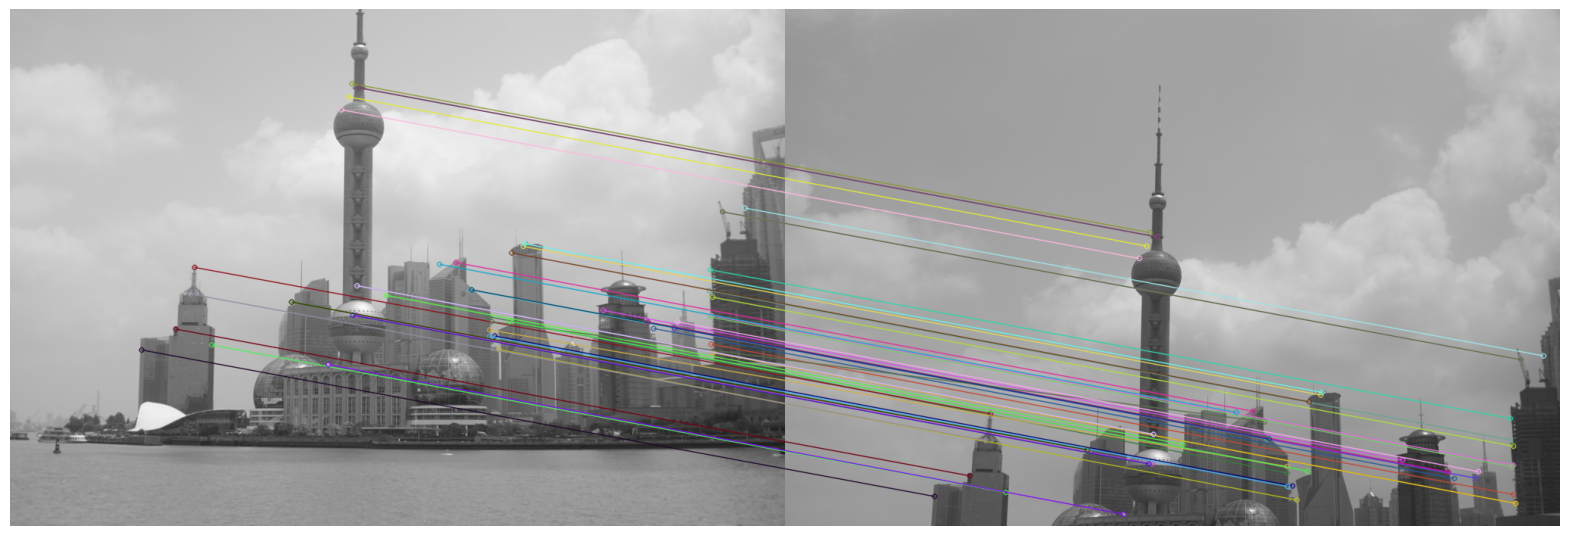

In [43]:
good_matches, keypoints1, keypoints2, descriptors1, descriptors2 = get_sift(gray_img1, gray_img2)
good_matches = good_matches[:50]
img_matches = cv2.drawMatches(gray_img1, keypoints1, gray_img2, keypoints2, good_matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(20, 10))
plt.imshow(img_matches)
plt.axis('off')
plt.show()

### Compute Homography Matrix between first two images

In [44]:
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in good_matches])
H, _=compute_homography_rnsac(src_pts, dst_pts)

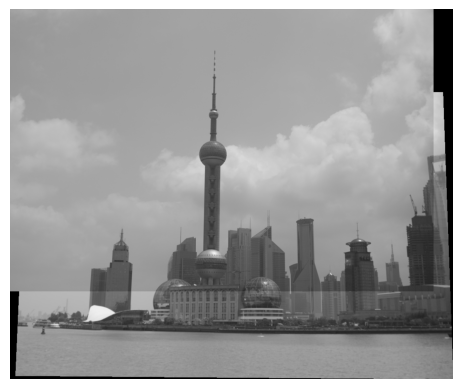

In [45]:
pano1 = create_pano(img1, img2, H)

plt.imshow(cv2.cvtColor(pano1, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### Viewing the Good matches between Resulted pano1 and image 3


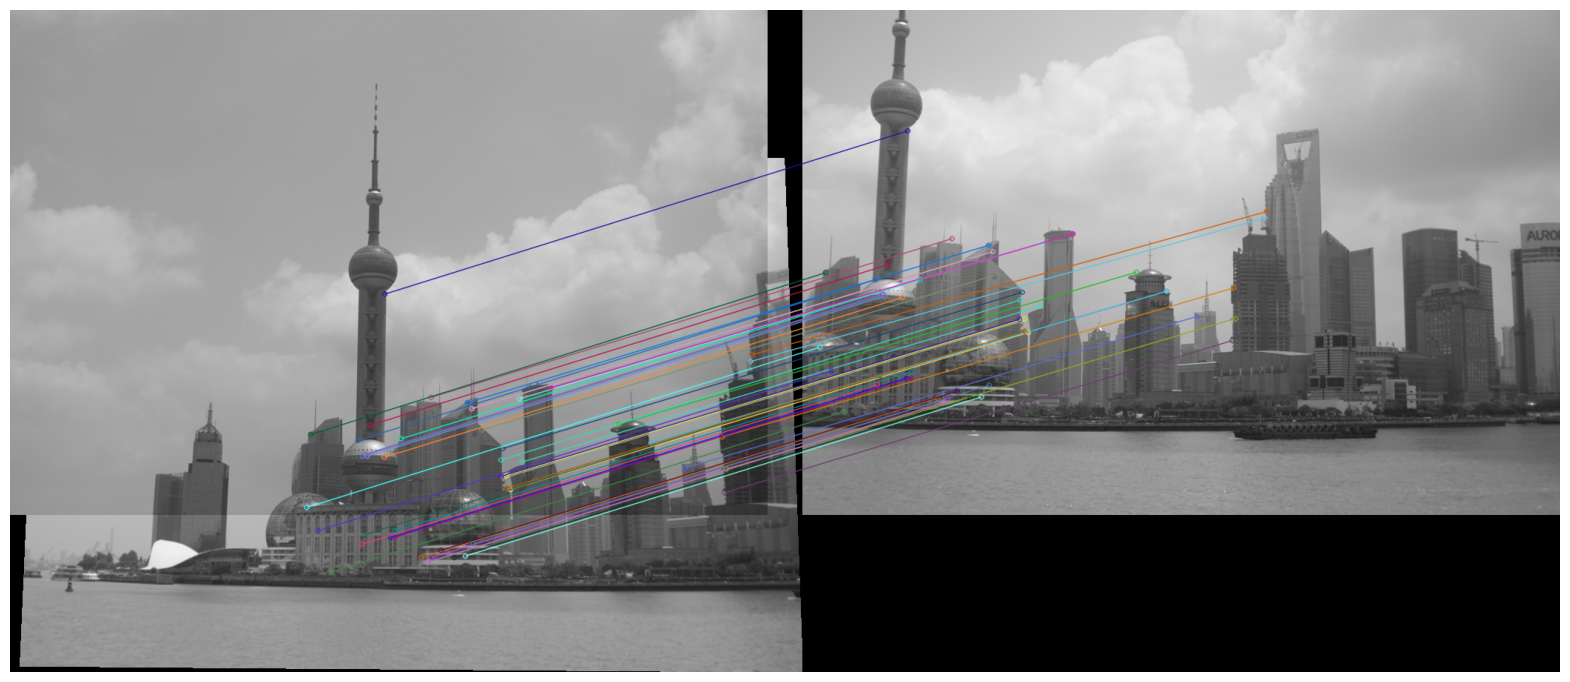

In [46]:
good_matches, keypoints1, keypoints2, descriptors1, descriptors2 = get_sift(pano1, gray_img3)
good_matches = good_matches[:50]
img_matches = cv2.drawMatches(pano1, keypoints1, gray_img3, keypoints2, good_matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(20, 10))
plt.imshow(img_matches)
plt.axis('off')
plt.show()

### Compute Homography Matrix between Resulted pano1 and image 3

In [47]:
src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in good_matches])
H, _=compute_homography_rnsac(src_pts, dst_pts)

### Final Result

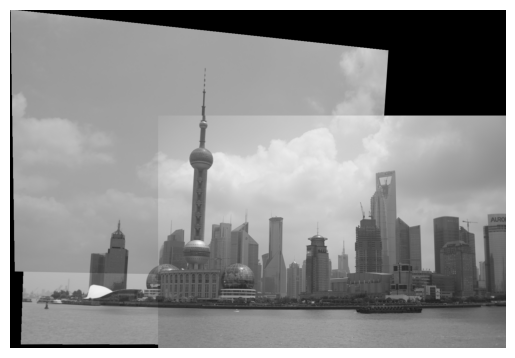

True

In [48]:
pano = create_pano(pano1, img3, H)

plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
cv2.imwrite('3-images.jpg', pano)